## Andria Linfante
### BINF 5312 Spring 2025
### Term Project - Further Analysis
Due 4/22/25

### Import Library and Results CSVs from All Models

In [61]:
import pandas as pd

sentiment_df = pd.read_csv('sentiment_results.csv')
ner_df = pd.read_csv('ner_results.csv')
aspects_df = pd.read_csv('reviews_with_aspects.csv')
original_df = pd.read_csv('psych_drug_webmd_reviews.csv')

In [62]:
# Filter NER results to re-aggregate to make a master df
ner_effects = ner_df[ner_df['label'] == 'EFFECT']

ner_effects_agg = ner_effects.groupby('review_index')['label'].apply(lambda x: list(set(x))).reset_index()

In [63]:
ner_effects_agg.head()

,review_index,label
0,0,[EFFECT]
1,1,[EFFECT]
2,2,[EFFECT]
3,3,[EFFECT]
4,5,[EFFECT]


In [64]:
# Relabel Index Column from Aspects Results
aspects_df.rename(columns={'Unnamed: 0': 'review_index'}, inplace=True)
aspects_df.head(2)

,review_index,drug_name,date,age,gender,time_on_drug,reviewer_type,condition,rating_overall,rating_effectiveness,rating_ease_of_use,rating_satisfaction,text,cleaned_text,drug_name_first_word,aspects
0,0,Sertraline Oral,2024-05-12,45-54,Female,1 to less than 2 years,Patient,Posttraumatic Stress Syndrome,5.0,5,5,5,It's almost two years now and it has been so e...,almost two year effective havent overthinking ...,Sertraline,['anxious depressed suicidal thought able proc...
1,1,Sertraline Oral,2024-04-21,35-44,Female,less than 1 month,Patient,Depression,1.0,1,1,1,Iv been on this 4 weeks and iv never felt so a...,iv week iv never felt angry irritable stressed...,Sertraline,"['iv', 'angry irritable stressed low mood', 'r..."


In [65]:
# Add and Label an Index Column for Sentiment Results
sentiment_df['review_index'] = sentiment_df.index
sentiment_df.head(2)

,condition,drug_name_first_word,rating_overall,rating_effectiveness,rating_ease_of_use,rating_satisfaction,vader_sentiment,review_index
0,Posttraumatic Stress Syndrome,Sertraline,5.0,5,5,5,positive,0
1,Depression,Sertraline,1.0,1,1,1,positive,1


In [86]:
# Select Colums to be Added to Final DF
sentiment_subset = sentiment_df[['review_index', 'vader_sentiment']]
ner_subset = ner_effects_agg[['review_index', 'label']]

In [89]:
# Merge Columns into Final DF
merged_df = aspects_df.merge(sentiment_subset, on='review_index', how='left')
merged_df = merged_df.merge(ner_subset, on='review_index', how='left')
merged_df.rename(columns={'label': 'ner_labels'}, inplace=True)
merged_df.head(5)

,review_index,drug_name,date,age,gender,time_on_drug,reviewer_type,condition,rating_overall,rating_effectiveness,rating_ease_of_use,rating_satisfaction,text,cleaned_text,drug_name_first_word,aspects,vader_sentiment,ner_labels
0,0,Sertraline Oral,2024-05-12,45-54,Female,1 to less than 2 years,Patient,Posttraumatic Stress Syndrome,5.0,5,5,5,It's almost two years now and it has been so e...,almost two year effective havent overthinking ...,Sertraline,['anxious depressed suicidal thought able proc...,positive,[EFFECT]
1,1,Sertraline Oral,2024-04-21,35-44,Female,less than 1 month,Patient,Depression,1.0,1,1,1,Iv been on this 4 weeks and iv never felt so a...,iv week iv never felt angry irritable stressed...,Sertraline,"['iv', 'angry irritable stressed low mood', 'r...",positive,[EFFECT]
2,2,Sertraline Oral,2024-04-16,25-34,Female,2 to less than 5 years,Patient,Repeated Episodes of Anxiety,4.3,4,4,5,Been taking sertraline for past 3 years. Had n...,taking sertraline past year side effect anxiet...,Sertraline,"['sertraline', 'past year side effect anxiety ...",negative,[EFFECT]
3,3,Sertraline Oral,2024-04-11,45-54,Male,less than 1 month,Patient,Panic Disorder,1.7,1,3,1,"Of course, take this with a pinch of salt beca...",course take pinch salt everyones chemistry dif...,Sertraline,"['pinch salt', 'chemistry', 'different definit...",negative,[EFFECT]
4,4,Sertraline Oral,2024-04-08,13-18,Female,NaN,Patient,Major Depressive Disorder,3.0,2,4,3,used for a while saw no effects.,used saw effect,Sertraline,['saw effect'],neutral,NaN


In [90]:
print(merged_df.columns)

Index(['review_index', 'drug_name', 'date', 'age', 'gender', 'time_on_drug',
       'reviewer_type', 'condition', 'rating_overall', 'rating_effectiveness',
       'rating_ease_of_use', 'rating_satisfaction', 'text', 'cleaned_text',
       'drug_name_first_word', 'aspects', 'vader_sentiment', 'ner_labels'],
      dtype='object')


### Download New Merged DF

In [82]:
merged_df.to_csv("merged_df.csv", index=False)

In [83]:
from google.colab import files
files.download("merged_df.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Cross Examine NLP Results

In [93]:
# Average Satisfaction w/ and w/o Side Effects
sat_eff_df = merged_df[['rating_satisfaction', 'ner_labels']].copy()
sat_eff_df.head()

,rating_satisfaction,ner_labels
0,5,[EFFECT]
1,1,[EFFECT]
2,5,[EFFECT]
3,1,[EFFECT]
4,3,NaN


In [94]:
sat_eff_df['has_effect'] = sat_eff_df['ner_labels'].astype(str).str.contains('EFFECT').astype(int)
sat_eff_df.head()

,rating_satisfaction,ner_labels,has_effect
0,5,[EFFECT],1
1,1,[EFFECT],1
2,5,[EFFECT],1
3,1,[EFFECT],1
4,3,NaN,0


(0.0, 10.0)

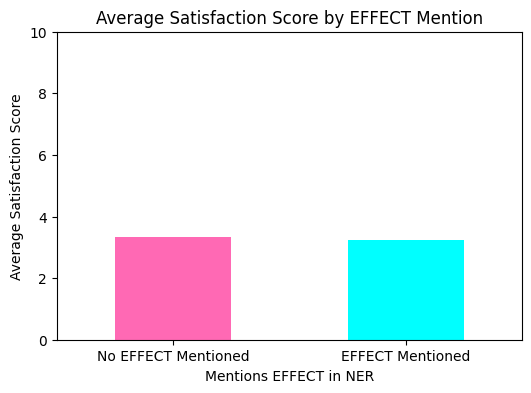

In [96]:
import matplotlib.pyplot as plt

avg_scores = sat_eff_df.groupby('has_effect')['rating_satisfaction'].mean()

plt.figure(figsize=(6, 4))
avg_scores.plot(kind='bar', color=['hotpink', 'cyan'])
plt.title('Average Satisfaction Score by EFFECT Mention')
plt.xlabel('Mentions EFFECT in NER')
plt.ylabel('Average Satisfaction Score')
plt.xticks(ticks=[0,1], labels=['No EFFECT Mentioned', 'EFFECT Mentioned'], rotation=0)
plt.ylim(0, 10)

In [108]:
avg_scores

,rating_satisfaction
has_effect,
0,3.334416
1,3.243457


In [97]:
# Sentiment w/ and w/o Side Effects
sent_eff_df = merged_df[['vader_sentiment', 'ner_labels']].copy()
sent_eff_df.head()

,vader_sentiment,ner_labels
0,positive,[EFFECT]
1,positive,[EFFECT]
2,negative,[EFFECT]
3,negative,[EFFECT]
4,neutral,NaN


In [98]:
sent_eff_df['has_effect'] = sent_eff_df['ner_labels'].astype(str).str.contains('EFFECT').astype(int)
sent_eff_df.head()

,vader_sentiment,ner_labels,has_effect
0,positive,[EFFECT],1
1,positive,[EFFECT],1
2,negative,[EFFECT],1
3,negative,[EFFECT],1
4,neutral,NaN,0


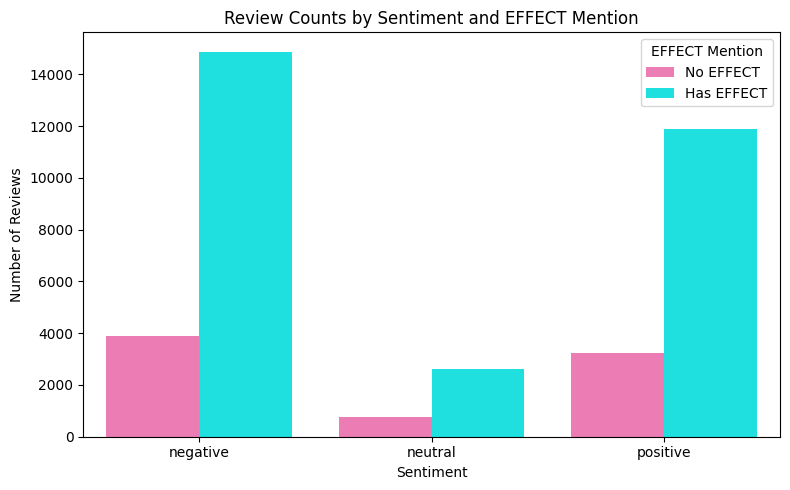

In [106]:
import seaborn as sns

effect_counts = sent_eff_df.groupby(['vader_sentiment', 'has_effect']).size().reset_index(name='count')

effect_counts['effect_label'] = effect_counts['has_effect'].map({1: 'Has EFFECT', 0: 'No EFFECT'})

my_colors = ['hotpink', 'cyan']

plt.figure(figsize=(8, 5))
sns.barplot(data=effect_counts, x='vader_sentiment', y='count', hue='effect_label', palette=my_colors)

plt.title('Review Counts by Sentiment and EFFECT Mention')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.legend(title='EFFECT Mention')
plt.tight_layout()
plt.show()

In [107]:
effect_counts

,vader_sentiment,has_effect,count,effect_label
0,negative,0,3883,No EFFECT
1,negative,1,14877,Has EFFECT
2,neutral,0,751,No EFFECT
3,neutral,1,2624,Has EFFECT
4,positive,0,3216,No EFFECT
5,positive,1,11873,Has EFFECT
